In [9]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

def plot_robot_trajectories(csv_path):
    """
    Lit un fichier CSV de log (DataLog EV3 ou CSV manuel)
    et trace les trajectoires du robot pour les trois méthodes :
    odométrie, gyroscope et modèle cinématique.
    """

    # Chargement du fichier CSV
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"❌ Erreur de lecture du fichier CSV : {e}")
        return

    # Nettoyage des noms de colonnes (enlève espaces avant/après)
    df.columns = df.columns.str.strip()

    # Vérification des colonnes attendues
    required_cols = ['x_odo', 'y_odo', 'x_gyro', 'y_gyro', 'x_model', 'y_model']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"⚠️ Colonnes manquantes dans le CSV : {missing}")
        print("Colonnes disponibles :", list(df.columns))
        return

    # Création de la figure
    plt.figure(figsize=(8, 8))
    plt.title("Trajectoires du robot selon les différentes méthodes")
    plt.xlabel("Position X (mm)")
    plt.ylabel("Position Y (mm)")
    plt.grid(True)

    # Tracés des trajectoires
    plt.plot(df['x_odo'], df['y_odo'], label='Odométrie', linewidth=2)
    plt.plot(df['x_gyro'], df['y_gyro'], label='Gyroscope', linewidth=2)
    plt.plot(df['x_model'], df['y_model'], label='Modèle cinématique', linewidth=2, linestyle='--')

    # Légende et aspect graphique
    plt.legend()
    plt.axis('equal')  # proportions réelles
    plt.show()


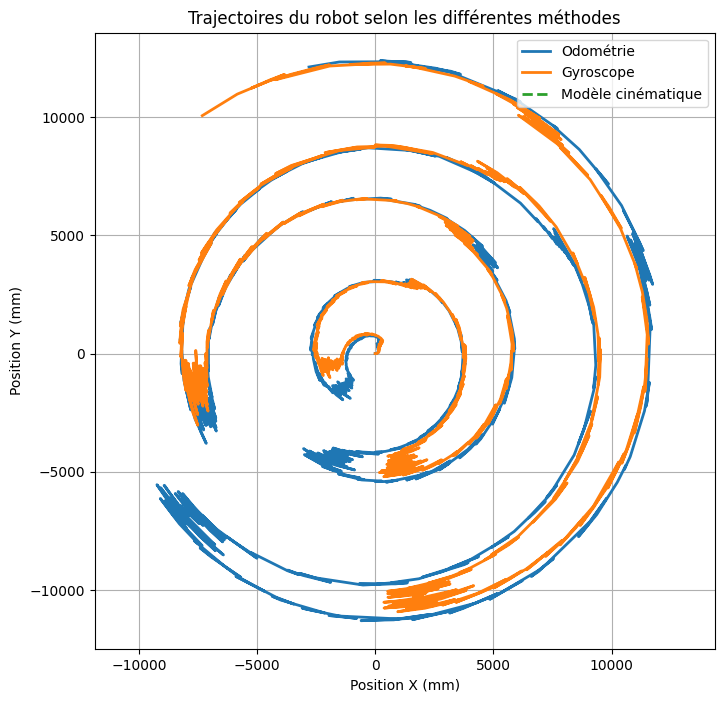

In [10]:
path = "TP_Kalman_13_10_2025_2025_10_13_15_52_21_391011.csv"
plot_robot_trajectories(path)

In [11]:
df = pd.read_csv(path)
df.columns

Index(['time', ' x_odo', ' y_odo', ' theta_odo', ' x_gyro', ' y_gyro',
       ' theta_gyro', ' x_model', ' y_model', ' theta_model',
       ' vitesse_lineaire'],
      dtype='object')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_robot_trajectories(csv_path, step=10):
    """
    Lit un fichier CSV de log (DataLog EV3 ou CSV manuel)
    et trace les trajectoires du robot pour les trois méthodes :
    odométrie, gyroscope et modèle cinématique,
    avec les angles d'orientation sous forme de flèches.
    
    Args:
        csv_path (str): chemin du fichier CSV
        step (int): intervalle entre deux flèches (plus grand = moins de flèches)
    """

    # Chargement du fichier CSV
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"❌ Erreur de lecture du fichier CSV : {e}")
        return

    # Nettoyage des noms de colonnes (supprime espaces parasites)
    df.columns = df.columns.str.strip()

    # Vérification des colonnes attendues
    required_cols = [
        'x_odo', 'y_odo', 'theta_odo',
        'x_gyro', 'y_gyro', 'theta_gyro',
        'x_model', 'y_model', 'theta_model'
    ]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"⚠️ Colonnes manquantes dans le CSV : {missing}")
        print("Colonnes disponibles :", list(df.columns))
        return

    # Création de la figure
    plt.figure(figsize=(8, 8))
    plt.title("Trajectoires du robot (avec orientation)")
    plt.xlabel("Position X (mm)")
    plt.ylabel("Position Y (mm)")
    plt.grid(True)

    # ------------------------
    # Méthode 1 : Odométrie
    # ------------------------
    plt.plot(df['x_odo'], df['y_odo'], label='Odométrie', linewidth=2, color='tab:blue')
    # Flèches d’orientation
    plt.quiver(
        df['x_odo'][::step], df['y_odo'][::step],
        np.cos(np.radians(df['theta_odo'][::step])),
        np.sin(np.radians(df['theta_odo'][::step])),
        angles='xy', scale_units='xy', scale=10, width=0.003, color='tab:blue', alpha=0.6
    )

    # ------------------------
    # Méthode 2 : Gyroscope
    # ------------------------
    plt.plot(df['x_gyro'], df['y_gyro'], label='Gyroscope', linewidth=2, color='tab:green')
    plt.quiver(
        df['x_gyro'][::step], df['y_gyro'][::step],
        np.cos(np.radians(df['theta_gyro'][::step])),
        np.sin(np.radians(df['theta_gyro'][::step])),
        angles='xy', scale_units='xy', scale=10, width=0.003, color='tab:green', alpha=0.6
    )

    # ------------------------
    # Méthode 3 : Modèle cinématique
    # ------------------------
    plt.plot(df['x_model'], df['y_model'], label='Modèle cinématique', linewidth=2, linestyle='--', color='tab:orange')
    plt.quiver(
        df['x_model'][::step], df['y_model'][::step],
        np.cos(np.radians(df['theta_model'][::step])),
        np.sin(np.radians(df['theta_model'][::step])),
        angles='xy', scale_units='xy', scale=10, width=0.003, color='tab:orange', alpha=0.6
    )

    # Aspect graphique
    plt.legend()
    plt.axis('equal')  # pour garder les proportions
    plt.show()


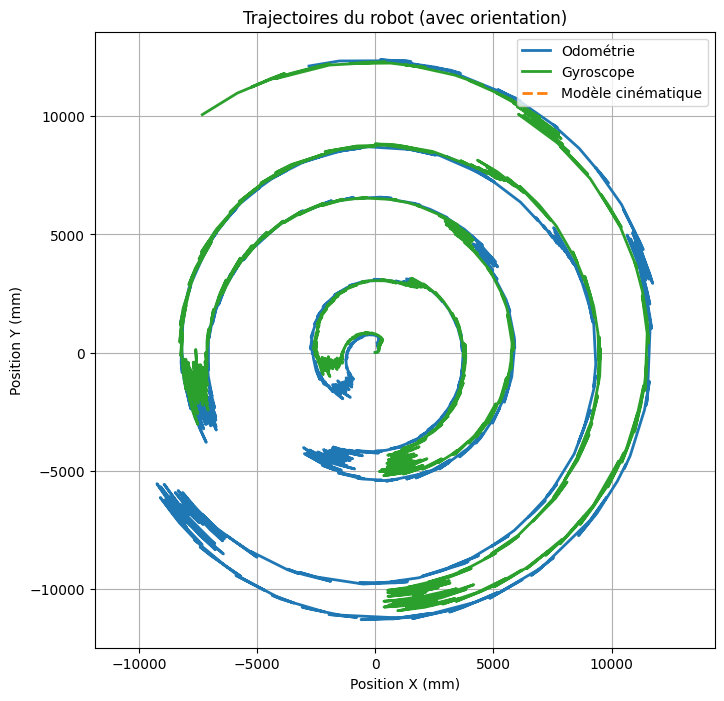

In [13]:
plot_robot_trajectories("TP_Kalman_13_10_2025_2025_10_13_15_52_21_391011.csv", step=20)


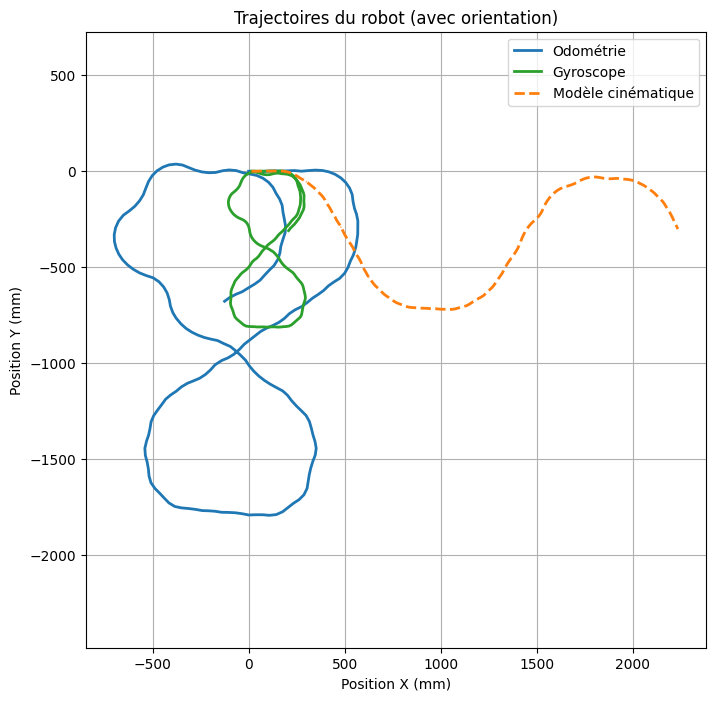

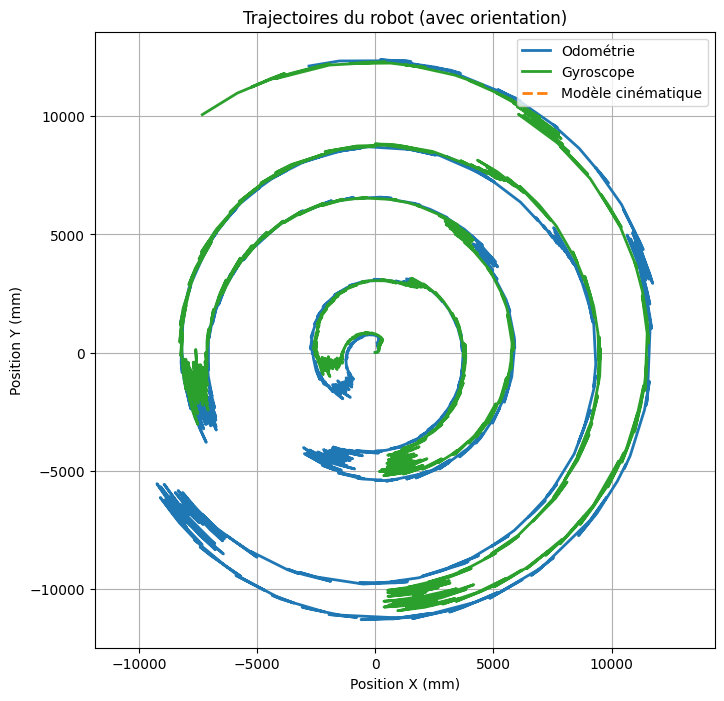

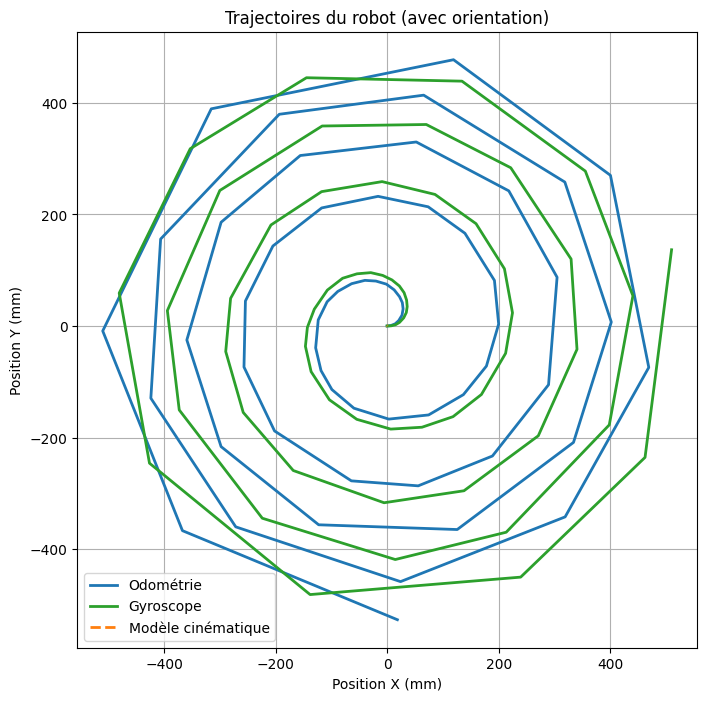

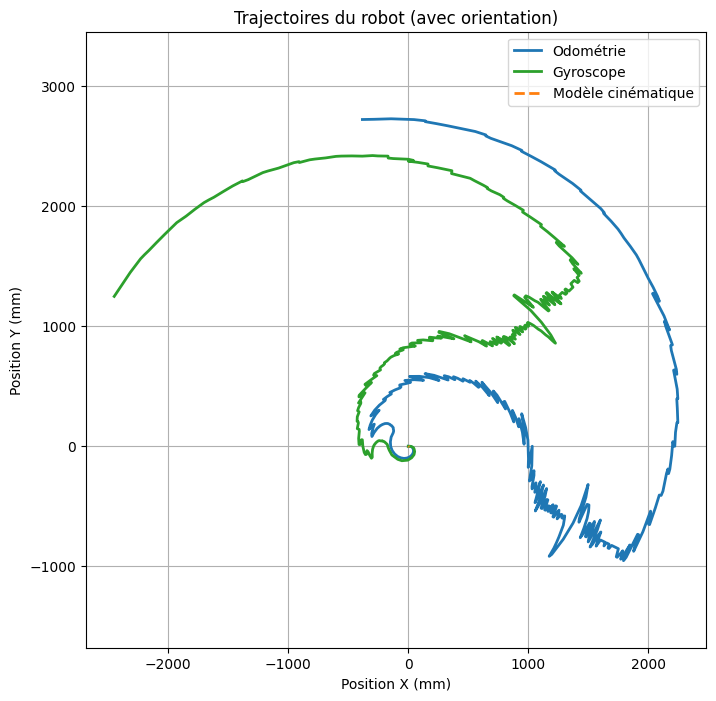

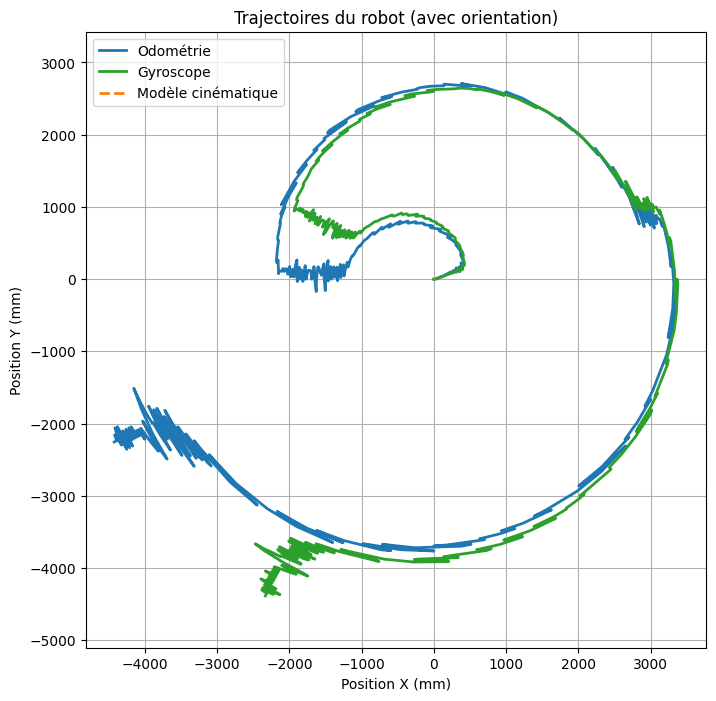

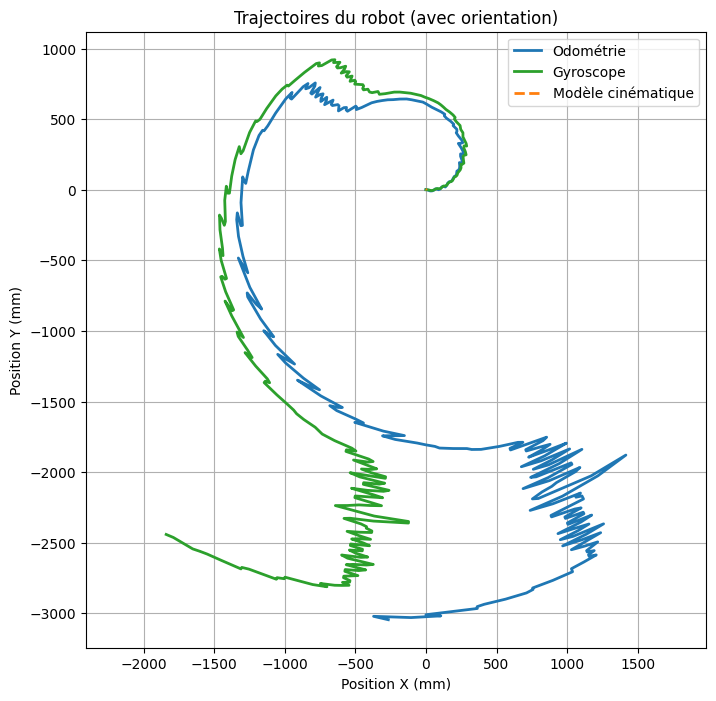

In [2]:
import os
for file in os.listdir('.'):
    if file.endswith('.csv'):
        plot_robot_trajectories(file, step=20)